# Introduction aux indices spectraux ou radiométriques

## Le spectre électromagnétique

Le rayonnement électromagnétique se propage sous forme d'ondes caractérisées par leur **longueur d'onde** (λ). L'œil humain ne perçoit qu'une infime portion du spectre — le **visible**, entre 400 et 700 nm. Les capteurs satellitaires exploitent des domaines bien plus larges.

Une bande spectrale correspond à un intervalle précis de longueurs d’onde de la lumière que capte un capteur. Le capteur enregistre la réflectance de la surface terrestre dans plusieurs bandes. Les satellites mesurent la réflectance de la surface terrestre dans différentes portions du spectre électromagnétique :

- **Visible (bleu, vert, rouge)** : correspond aux couleurs perceptibles par l’œil humain.
- **Proche infrarouge (NIR)** : particulièrement utile pour l’analyse de la végétation et de son état de santé.
- **Infrarouge à ondes courtes (SWIR)** : permet de caractériser l’humidité des sols et de la végétation, ainsi que de mieux distinguer l’eau, les nuages et certaines surfaces minérales.

</br>

<img src="images/PC2.15.INF4_bis_v1.webp" width="800">

---

## Réflectance spectrale

La **réflectance** est le rapport entre l'énergie réfléchie par une surface et l'énergie incidente : une surface blanche a une réflectance de 1 (100%), une surface noire de 0. Chaque type de surface a une **signature spectrale** caractéristique — une courbe de réflectance unique selon la longueur d'onde. C'est cette signature que les indices spectraux exploitent :

- Une **végétation** en bon état capte une grande partie du rayonnement dans le rouge pour alimenter la photosynthèse, tandis qu’elle renvoie une proportion importante du proche infrarouge.
- Les **surfaces en eau**, quant à elles, absorbent la majeure partie de l’énergie incidente et ne réfléchissent qu’une faible quantité de lumière, notamment dans le domaine du proche infrarouge.
- Les **sols nus** présentent généralement une réflectance qui augmente graduellement lorsque la longueur d’onde croît.

<img src="images/spectral_signatures_landsat.jpg" width="800">

---

## C'est quoi un indice spectral ?

Un indice spectral (ou radiométrique) est une combinaison mathématique de bandes spectrales mesurées par un capteur. Il permet de transformer les données brutes en indicateurs utiles pour analyser la végétation, l'eau, les sols ou l'occupation du sol, en exploitant les propriétés de la lumière réfléchie par les surfaces terrestres.

---

## Principes et Formules

Un **indice spectral** est une combinaison mathématique de plusieurs bandes d'une image satellitaire. Il amplifie le signal d'un type de surface particulier (végétation, eau, sol...) tout en atténuant les autres. Un indice spectral repose sur la normalisation de ces différences de réflectance. La formule générale est un rapport de plusieurs bandes spectrales tel que :

$$\text{Indice} = \frac{A - B}{A + B}$$

Ce ratio normalisé produit toujours une valeur entre **−1 et +1**, ce qui le rend comparable entre images, dates et satellites.  
- Proche de **+1** → la surface répond fortement à la bande A
- Proche de **−1** → la surface répond fortement à la bande B
- Proche de **0**  → pas de différence entre les deux bandes

---

## Principaux indices de télédétection

### Indices de végétation

La végétation verte absorbe fortement le rouge (pour la photosynthèse) et réfléchit fortement le proche infrarouge (NIR). Cette opposition `Rouge / NIR` est la base de tous les indices de végétation. 

```
Réflectance
    ▲
    │        NIR
    │       ╱╲
    │      ╱  ╲
    │     ╱    ╲_______ SWIR
    │____╱
    │  Rouge absorbé
    └─────────────────► Longueur d'onde
```


#### NDVI (Normalized Difference Vegetation Index)

L'indice de végétation le plus utilisé au monde :) Le NDVI mesure la densité et la vigueur de la végétation verte.

$$\text{NDVI} = \frac{\text{NIR} - \text{Rouge}}{\text{NIR} + \text{Rouge}}$$

| Valeur | Interprétation |
|--------|----------------|
| < 0    | Eau, nuages, neige |
| 0 – 0.1 | Sol nu, roche, sable |
| 0.1 – 0.3 | Végétation éparse, prairies sèches |
| 0.3 – 0.6 | Végétation modérée, cultures |
| > 0.6  | Forêt dense, végétation très vigoureuse |


#### EVI — Enhanced Vegetation Index

L'indice **EVI** est un indice de végétation similaire au NDVI et permet d’évaluer la vigueur et la densité du couvert végétal. Toutefois, l’**EVI** corrige certains effets atmosphériques ainsi que l’influence du sol et de la structure du couvert végétal. Il est également plus sensible que le NDVI dans les zones à végétation dense, où ce dernier a tendance à saturer.

$$\text{EVI} = 2.5 \times \frac{\text{NIR} - \text{Rouge}}{\text{NIR} + 6 \times \text{Rouge} - 7.5 \times \text{Bleu} + 1}$$

**Quand l'utiliser à la place du NDVI ?**
- En zones de forêt tropicale dense (le NDVI sature à 0.8–0.9)
- En présence d'aérosols importants
- Pour des analyses dans des zones avec un fort signal de sol


#### SAVI — Soil Adjusted Vegetation Index

L'indice corrige l'influence du sol sous la végétation, utile en zones semi-arides avec végétation éparse.

$$\text{SAVI} = \frac{\text{NIR} - \text{Rouge}}{\text{NIR} + \text{Rouge} + 0.5} \times (1.5)$$

---

### Indices d'eau

L'eau absorbe fortement le NIR et le SWIR, et réfléchit le vert. Les indices d'eau exploitent cette opposition Vert–NIR ou Vert–SWIR.

#### NDWI — Normalized Difference Water Index (McFeeters, 1996)

Le **NDWI** les surfaces en eau libre (lacs, rivières, zones inondées).

$$\text{NDWI} = \frac{\text{Vert} - \text{NIR}}{\text{Vert} + \text{NIR}}$$

| Valeur | Interprétation |
|--------|----------------|
| > 0.3  | Eau libre |
| 0 – 0.3 | Zone humide, eau turbide |
| < 0    | Sol, végétation, bâti |


#### MNDWI — Modified NDWI (Xu, 2006)

Le **MNDWI** remplace le NIR par le SWIR1 pour mieux séparer l'eau des zones urbaines et végétalisées. Cela aboutit à moins de confusion entre eau et bâti (qui réfléchit aussi dans le NIR). 

$$\text{MNDWI} = \frac{\text{Vert} - \text{SWIR1}}{\text{Vert} + \text{SWIR1}}$$

---

### Indices de bâti / zones urbaines

Les surfaces imperméables (béton, asphalte, toits) réfléchissent fortement dans le SWIR et peu dans le NIR, l'inverse de la végétation.

#### NDBI — Normalized Difference Built-up Index (Zha, 2003)

Le **NDBI** est un indice spectral conçu pour identifier et cartographier les zones urbanisées. Il exploite le contraste entre le proche infrarouge (NIR) et l’infrarouge à ondes courtes (SWIR), les surfaces bâties ayant généralement une réflectance plus élevée dans le SWIR que dans le NIR. Des valeurs élevées de NDBI indiquent souvent la présence d’infrastructures urbaines

$$\text{NDBI} = \frac{\text{SWIR1} - \text{NIR}}{\text{SWIR1} + \text{NIR}}$$

| Valeur | Interprétation |
|--------|----------------|
| > 0    | Zone bâtie, sol nu |
| < 0    | Végétation, eau |

⚠️ Le NDBI seul confond souvent bâti et sol nu. Il est plus efficace combiné au NDVI (soustraction).

#### UI — Urban Index

L'indice **UI** est similaire au **NDBI** mais utilise SWIR2 (plus sensible aux matériaux de construction).

$$\text{UI} = \frac{\text{SWIR2} - \text{NIR}}{\text{SWIR2} + \text{NIR}}$$

#### BUI — Built-Up Index (He et al., 2010)

Le **BUI** est construite par une combinaison du **NDBI** et du **NDVI** pour mieux isoler le bâti :

$$\text{BUI} = \text{NDBI} - \text{NDVI}$$

---

### Indices de sol nu

Le sol nu réfléchit de façon relativement uniforme dans le visible et le SWIR, avec une réflectance plus faible dans le NIR que la végétation.

#### BSI — Bare Soil Index (Rikimaru et al., 2002)

Le **BSI** est un indice spectral conçu pour identifier les sols nus et les surfaces faiblement couvertes par la végétation. Il exploite les contrastes de réflectance entre les bandes bleu (Blue), rouge (Red), proche infrarouge (NIR) et infrarouge à ondes courtes (SWIR). Les sols nus présentent généralement une réflectance plus élevée dans le rouge et le SWIR que dans le NIR, ce qui permet de les distinguer de la végétation et des plans d’eau.

$$\text{BSI} = \frac{(\text{SWIR1} + \text{Rouge}) - (\text{NIR} + \text{Bleu})}{(\text{SWIR1} + \text{Rouge}) + (\text{NIR} + \text{Bleu})}$$

| Valeur | Interprétation |
|--------|----------------|
| > 0    | Sol nu, zones dégradées |
| < 0    | Végétation, eau |


#### NDSI — Normalized Difference Soil Index

Identique au **BSI** mais plus simple, basé sur un contraste direct SWIR–vert

$$\text{NDSI} = \frac{\text{SWIR1} - \text{Vert}}{\text{SWIR1} + \text{Vert}}$$

> ⚠️ A pas confondre avec le **NDSI Neige** (Snow Index) qui utilise Vert–SWIR1 (ordre inversé).

---

### Indice d'humidité

#### LSWI — Land Surface Water Index

L'indice des eaux de surface terrestres (**LSWI**) a été mis au point par Xiao et al. afin de surveiller la végétation et la teneur en eau du sol. Le **LSWI** est sensible à la présence d'eau liquide dans la végétation en raison de la forte absorption du spectre infrarouge proche (SWIR) par l'eau. Il est largement utilisé pour la surveillance de la sécheresse, la détection du stress hydrique et l'intégration dans des modèles de productivité végétale.

$$\text{LSWI} = \frac{\text{NIR} - \text{SWIR1}}{\text{SWIR1} + \text{NIR}}$$

Le seuil **LSWI > 0.3** est généralement utilisé dans la littérature pour identifier les surfaces en eau libre (*open water*), tandis que les valeurs plus faibles correspondent à des surfaces humides ou sèches.

---

### Récapitulatif — Quel indice pour quel objectif ?

| Objectif | Indice recommandé | Formule simplifiée |
|----------|-------------------|--------------------|
| Végétation dense | NDVI | (NIR−R)/(NIR+R) |
| Végétation éparse / semi-aride | SAVI | NDVI corrigé par L |
| Forêt tropicale dense | EVI | formule à 3 bandes |
| Eau libre | NDWI | (G−NIR)/(G+NIR) |
| Eau + zones humides | MNDWI | (G−SWIR1)/(G+SWIR1) |
| Zones bâties | NDBI | (SWIR1−NIR)/(SWIR1+NIR) |
| Bâti vs végétation | BUI | NDBI − NDVI |
| Sol nu | BSI | combinaison 4 bandes |
| Humidité | LSWI | (SWIR1-NIR)/(SWIR1+NIR) |

---

### Correspondance bandes Landsat

| Rôle | L5 / L7 | L8 |
|------|---------|----|
| Bleu | SR_B1 | SR_B2 |
| Vert | SR_B2 | SR_B3 |
| Rouge | SR_B3 | SR_B4 |
| NIR | SR_B4 | SR_B5 |
| SWIR1 | SR_B5 | SR_B6 |
| SWIR2 | SR_B7 | SR_B7 |


## Calcul d'indices spectraux avec python

### Librairies

Nous utilisons `rioxarray` pour lire les images, `spyndex` pour le calcul des indices spectraux, et la bibliothèque `matplotlib` pour afficher les résultats.

In [1]:
import os
import spyndex
import rasterio
import warnings
import numpy as np
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

### Travailler avec l'année 2015

#### Chargement et exploration de l'image composite médiane 2015

La fonction `rioxarray.open_rasterio` lit les fichiers **GeoTIFF** et met à disposition les informations géospatiales via l'objet `xarray`, notamment le SRC et la géométrie des pixels.

In [ ]:
L08_2015_path = "data/images_landsat/L08_2015.tif"

da_2015 = rxr.open_rasterio(L08_2015_path, masked=True)

print(da_2015)
print("shape:", da_2015.shape)
print("crs:", da_2015.rio.crs)
print("bounds:", da_2015.rio.bounds())
print("resolution:", da_2015.rio.resolution())

<xarray.DataArray (band: 7, y: 241, x: 455)> Size: 6MB
[767585 values with dtype=float64]
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * y            (y) float64 2kB 1.813e+06 1.813e+06 ... 1.806e+06 1.806e+06
  * x            (x) float64 4kB -1.839e+06 -1.839e+06 ... -1.825e+06 -1.825e+06
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0
shape: (7, 241, 455)
crs: EPSG:3857
bounds: (-1838850.0, 1805700.0, -1825200.0, 1812930.0)
resolution: (30.0, -30.0)


Renommer les bandes. Pour rappel, on a uniquement télécharger les images de réflectance. Pour Landsat 5, on a 6 bandes comme montré par la sortie ci-dessus. Rappelons les bandes de réflectance ci-desous :

---

## Landsat 8 — 2013–présent (OLI/TIRS)

| Bande GEE | Nom | Longueur d'onde | Résolution | Utilité principale |
|-----------|-----|-----------------|------------|--------------------|
| `SR_B1` | Coastal / Aérosols | 0.43–0.45 µm | 30 m | Zones côtières, aérosols, eau peu profonde |
| `SR_B2` | Bleu | 0.45–0.51 µm | 30 m | Eau, atmosphère, turbidité |
| `SR_B3` | Vert | 0.53–0.59 µm | 30 m | Végétation, réflectance verte |
| `SR_B4` | Rouge | 0.64–0.67 µm | 30 m | Chlorophylle, discrimination végétation/sol |
| `SR_B5` | Proche infrarouge (NIR) | 0.85–0.88 µm | 30 m | Biomasse végétale, eau/terre |
| `SR_B6` | SWIR 1 | 1.57–1.65 µm | 30 m | Humidité des sols et végétation |
| `SR_B7` | SWIR 2 | 2.11–2.29 µm | 30 m | Minéralogie, zones brûlées, sols nus |
| `SR_B10` | Thermique (TIRS 1) | 10.60–11.19 µm | 100 m (rééchantillonné 30 m) | Température de surface |
| `SR_B11` | Thermique (TIRS 2) | 11.50–12.51 µm | 100 m (rééchantillonné 30 m) | Température, correction atmosphérique |

---

Les six bandes correspondent dans l'ordre à toutes les bandes sauf la bande thermique SR_B6. Renommons les bandes.

In [6]:
band_names = ["Aerosol", "Bleu", "Vert", "Rouge", "NIR", "SWIR1", "SWIR2"]
da_2015 = da_2015.assign_coords(band=band_names)
print(da_2015)

<xarray.DataArray (band: 7, y: 241, x: 455)> Size: 6MB
[767585 values with dtype=float64]
Coordinates:
  * band         (band) <U7 196B 'Aerosol' 'Bleu' 'Vert' ... 'SWIR1' 'SWIR2'
  * y            (y) float64 2kB 1.813e+06 1.813e+06 ... 1.806e+06 1.806e+06
  * x            (x) float64 4kB -1.839e+06 -1.839e+06 ... -1.825e+06 -1.825e+06
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0


Visualisons la scène à l’aide de la bibliothèque `matplotlib`. Par exemple, pour afficher une composition colorée en utilisant les bandes 4, 3 et 2 (proche infrarouge, rouge et vert de Landsat 5), on peut créer une image RGB et la représenter graphiquement.

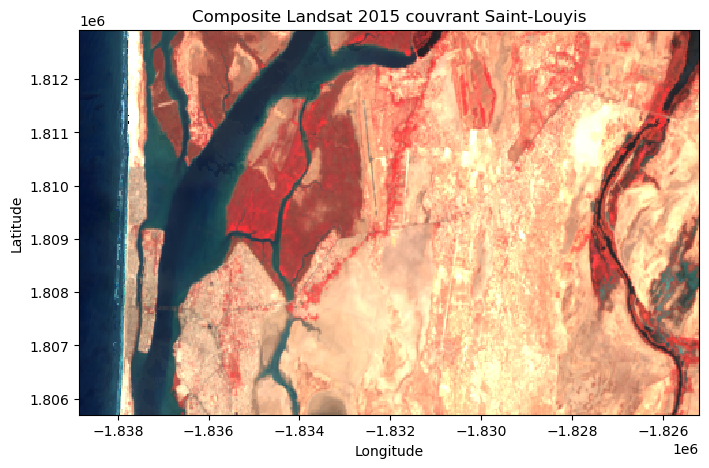

In [7]:
# Plot the raster data
plt.figure(figsize=(8, 5))
da_2015.sel(band=['NIR', 'Rouge', 'Vert']).plot.imshow(vmin=0, vmax=0.3)
plt.title("Composite Landsat 2015 couvrant Saint-Louyis")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

#### Introduction à **Spyndex**

**Spyndex** (souvent écrit par erreur **spyindex**) est une bibliothèque Python spécialisée dans le calcul d'indices spectraux utilisés en télédétection. Son objectif est simple : fournir une base standardisée de centaines d'indices (végétation, eau, sols, zones bâties, brûlis, neige, etc.) sans avoir à recoder chaque formule manuellement.

`Spyndex` met à disposition son catalogue d'indices spectraux directement via `spyndex.indices`, et sa documentation de référence sur l'API décrit la fonction `computeIndex()` ainsi que l'accès aux indices, aux bandes et aux constantes.

##### Exploration des indices spectraux disponibles

Les indices spectraux issus de la base de données [**Awesome Spectral Indices**](https://github.com/awesome-spectral-indices/awesome-spectral-indices) sont accessibles via l'objet `spyndex.indices`. Il s'agit d'un dictionnaire contenant l'ensemble des indices répertoriés dans la bibliothèque. Chaque indice peut être consulté individuellement afin d'obtenir ses principales caractéristiques, telles que son nom, sa formule, les bandes spectrales requises, sa catégorie d'application et sa référence bibliographique.

>La base de données [**Awesome Spectral Indices**](https://github.com/awesome-spectral-indices/awesome-spectral-indices) est une liste standardisée et prête à l'emploi d'indices spectraux sélectionnés avec soin, pouvant servir de formules pour le calcul d'indices spectraux dans les applications de télédétection.

Les indices spectraux de la base de données [**Awesome Spectral Indices**](https://github.com/awesome-spectral-indices/awesome-spectral-indices) sont accessibles via `spyndex.indices`. 

In [8]:
print("Nombre d'indices disponibles :", len(spyndex.indices))

Nombre d'indices disponibles : 273


Affichier la définition d'un indice spectral au choix (ex: NDVI)

In [9]:
# Description de l'indice NDVI
spyndex.indices["NDVI"]  # ou spyndex.indices.NDVI

SpectralIndex(NDVI: Normalized Difference Vegetation Index)
        * Application Domain: vegetation
        * Bands/Parameters: ['N', 'R']
        * Formula: (N-R)/(N+R)
        * Reference: https://ntrs.nasa.gov/citations/19740022614
        

In [10]:
# Obtenir la formule d'un indice
spyndex.indices["NDVI"].formula

'(N-R)/(N+R)'

In [11]:
# Référence d'un indice
spyndex.indices["NDVI"].reference

'https://ntrs.nasa.gov/citations/19740022614'

##### Constantes utilisées dans certains indices spectraux

Certains indices spectraux nécessitent l'utilisation de constantes numériques pour leur calcul. Ces constantes sont généralement définies par les auteurs des indices et interviennent dans les formules afin d'améliorer la sensibilité de l'indice à certaines caractéristiques de la surface observée.

Les valeurs par défaut de ces constantes sont accessibles via l'objet `spyndex.constants`. Celui-ci regroupe l'ensemble des constantes disponibles et permet d'accéder facilement à leurs valeurs.

In [12]:
print(spyndex.constants)

['C1', 'C2', 'L', 'PAR', 'alpha', 'beta', 'c', 'cexp', 'epsilon', 'fdelta', 'g', 'gamma', 'k', 'lambdaG', 'lambdaN', 'lambdaN2', 'lambdaR', 'lambdaS1', 'lambdaS2', 'n', 'nexp', 'omega', 'p', 'sigma', 'sla', 'slb']


L'exemple suivant permet d'accéder à la constante **L** (*Canopy Background Adjustment*), utilisée notamment dans le calcul de l'indice **SAVI** (*Soil Adjusted Vegetation Index*). Cette constante sert à réduire l'influence du sol lorsque la couverture végétale est faible ou discontinue.

In [13]:
# Facteur d'ajustement du fond de couvert végétal
spyndex.constants["L"]  # ou spyndex.constants.L

Constant(L: Canopy background adjustment)
        * Default value: 1.0
        

##### Paramètres des bandes spectrales

Les bandes spectrales standardisées utilisées par les indices de **Spyndex** sont accessibles via l'objet `spyndex.bands`. Cet objet regroupe les différentes bandes spectrales pouvant intervenir dans le calcul des indices (bleu, vert, rouge, proche infrarouge, infrarouge à ondes courtes, etc.), ainsi que leurs descriptions. Il permet de connaître la signification de chaque paramètre utilisé dans les formules des indices spectraux.

In [14]:
# Toutes les bandes
spyndex.bands

Bands(['A', 'B', 'G', 'G1', 'N', 'N2', 'R', 'RE1', 'RE2', 'RE3', 'S1', 'S2', 'T', 'T1', 'T2', 'WV', 'Y'])

In [15]:
# La bande bleu
spyndex.bands["B"]

Band(B: Blue)
        

##### Calcul d’un ou plusieurs indices spectraux

La méthode `computeIndex()` permet de calculer facilement des indices spectraux à partir de données satellitaires. Le paramètre `index` permet de spécifier un ou plusieurs indices à calculer, tandis que le paramètre `params` contient un dictionnaire regroupant les bandes spectrales nécessaires au calcul. Cette approche permet de calculer simultanément plusieurs indices (par exemple NDVI, NDWI, BSI, etc.) de manière simple et standardisée.

**Spyndex** a besoin d'un dictionnaire dont les clés correspondent aux noms symboliques des bandes utilisés par les formules d'indice choisies. Il est également possible de définir en même temps les valeurs des constants qui interviennent dans les indices à calculer. Nous pouvons procéder comme suit :

In [16]:
bands_map = {
    "N": da_2015.sel(band="NIR"),
    "R": da_2015.sel(band="Rouge"),
    "G": da_2015.sel(band="Vert"),
    "B": da_2015.sel(band="Bleu"),
    "S1": da_2015.sel(band="SWIR1"),
    "S2": da_2015.sel(band="SWIR2"),
    "L": 0.5
}

Ensuite, définisson une liste des indices qu'on veut calculer (NDVI, SAVI, MNDWI, NDBI, SMI) :

In [17]:
idx_list = ["NDVI","SAVI", "MNDWI", "NDBI", 'UI',  "LSWI"]

Maintenant utilisons la fonction **`spyndex.computeIndex`** pour calculer tous les indices en même temps :

In [18]:
indices = {
    name: spyndex.computeIndex(index=name, params=bands_map) for name in idx_list
}

Maintenant, visualisons les indices qu'on vien de calculer, en utilisant la bibliothèque **matplotlib**

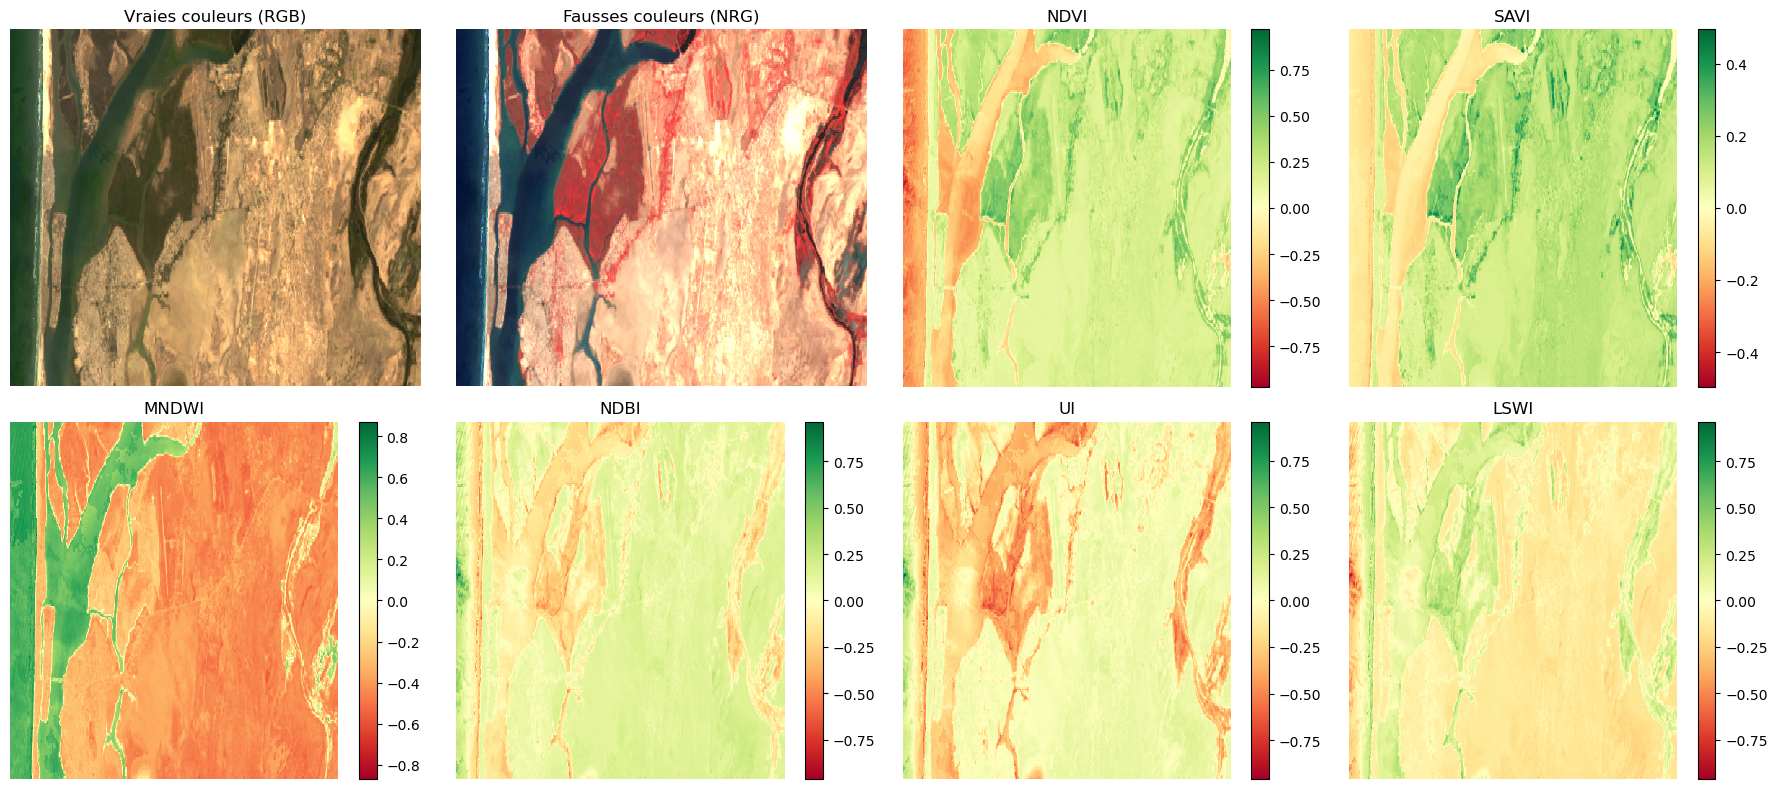

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax in axes:
    ax.axis("off")

da_2015.sel(band=["Rouge", "Vert", "Bleu"]).plot.imshow(ax=axes[0], vmin=0, vmax=0.3)
axes[0].set_title("Vraies couleurs (RGB)")

da_2015.sel(band=["NIR", "Rouge", "Vert"]).plot.imshow(ax=axes[1], vmin=0, vmax=0.3)
axes[1].set_title("Fausses couleurs (NRG)")

for i, idx in enumerate(idx_list):
    indices[idx].plot(ax=axes[i+2], cmap="RdYlGn")
    axes[i+2].set_title(idx)

plt.tight_layout()
plt.show()

---
### Exporter les indices calculés

Une fois les indices calculés, il est souvent utile de les sauvegarder sous forme de fichiers GeoTIFF afin de pouvoir les réutiliser dans d'autres logiciels SIG (QGIS, ArcGIS), les partager ou les analyser ultérieurement. Chaque indice sera exporté individuellement en conservant les informations géographiques du raster d'origine, notamment le système de coordonnées de référence (CRS) et la transformation affine. Les fichiers produits pourront ainsi être directement utilisés dans un environnement SIG sans traitement supplémentaire.

In [20]:
out_dir = "data/indices_2015"
os.makedirs(out_dir, exist_ok=True)

for name, arr in indices.items():
    arr = arr.rio.write_crs(da_2015.rio.crs)
    arr = arr.rio.write_transform(da_2015.rio.transform())
    arr.rio.to_raster(f"{out_dir}/{name}.tif")

---
### Seuillage des indices spectraux — Extraction de la végétation et de l'eau

#### Qu'est-ce que le seuillage ?

Le **seuillage** (ou *thresholding*) est la méthode de classification la plus simple en télédétection. Elle consiste à affecter une **classe** à chaque pixel selon sa valeur dans un indice spectral :

```
si NDVI ≥ 0.3  →  pixel classé "végétation modérée"
si NDVI < 0.1  →  pixel classé "non-végétation"
```
C'est une approche **non supervisée** — elle ne nécessite pas de données d'entraînement. Son principal avantage est la rapidité et l'interprétabilité, mais elle dépend fortement du choix des seuils, qui peuvent varier selon la saison, le type de sol ou la zone géographique.

Nous allons : 

1. Extraire les indices NDVI et MNDWI calculés avec **spyndex**
2. Appliquer un **seuillage** pour classifier les pixels de végétation
3. Extraire les surfaces en **eau libre** à partir du MNDWI
4. Visualiser et quantifier les résultats

---
#### Extraction des matrices de données (arrays)

`spyndex.computeIndex()` retourne un objet **xarray DataArray**.  On appelle `.values` pour récupérer le tableau numpy sous-jacent, qui est un simple tableau 2D de flottants (hauteur × largeur) avec des valeurs entre −1 et +1.

In [21]:
NDVI  = indices['NDVI'].values
MNDWI = indices['MNDWI'].values

print(f"Dimensions de l'image : {NDVI.shape}")
print()
print("Statistiques NDVI :")
print(f"  Min    : {np.nanmin(NDVI):.3f}")
print(f"  Max    : {np.nanmax(NDVI):.3f}")
print(f"  Moyenne: {np.nanmean(NDVI):.3f}")
print(f"  Médiane: {np.nanmedian(NDVI):.3f}")
print()
print("Statistiques MNDWI :")
print(f"  Min    : {np.nanmin(MNDWI):.3f}")
print(f"  Max    : {np.nanmax(MNDWI):.3f}")
print(f"  Moyenne: {np.nanmean(MNDWI):.3f}")
print(f"  Médiane: {np.nanmedian(MNDWI):.3f}")

Dimensions de l'image : (241, 455)

Statistiques NDVI :
  Min    : -0.968
  Max    : 0.725
  Moyenne: 0.112
  Médiane: 0.169

Statistiques MNDWI :
  Min    : -0.587
  Max    : 0.869
  Moyenne: -0.205
  Médiane: -0.378


---
#### Exploration des distributions des valeurs des pixels

Avant d'appliquer des seuils, il est indispensable d'examiner la **distribution des valeurs**  à travers un histogramme. Cela permet de :
- Vérifier que les valeurs sont dans la plage attendue (−1 à +1)
- Identifier les modes (pics) qui correspondent à des types de surface
- Choisir des seuils cohérents avec la distribution réelle de la zone d'étude

Par exemple, un histogramme bimodal (deux pics) sur le NDVI indique typiquement une séparation nette entre végétation et non-végétation — idéal pour le seuillage.

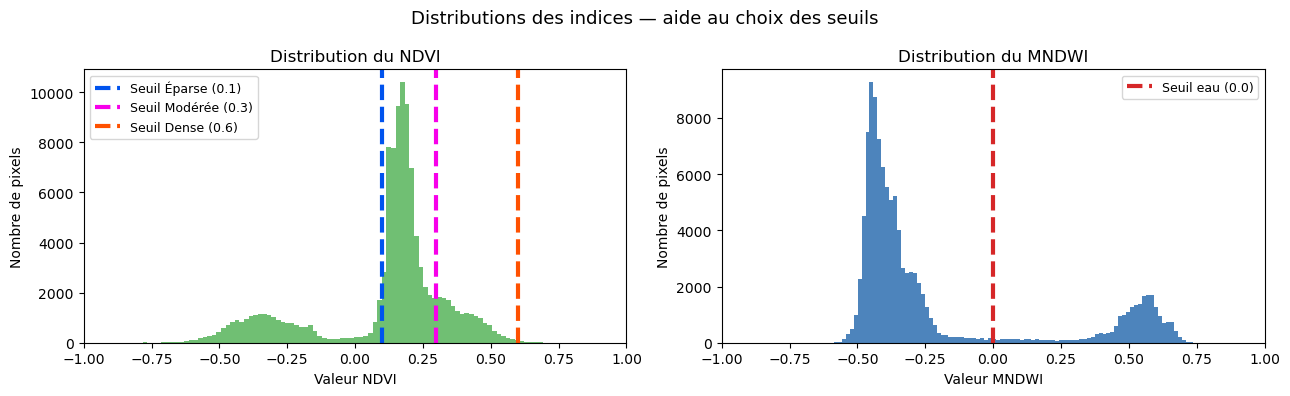

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme NDVI
ax = axes[0]
vals_ndvi = NDVI[~np.isnan(NDVI)].ravel()
ax.hist(vals_ndvi, bins=100, color='#4caf50', edgecolor='none', alpha=0.8)
# Lignes de seuil
for seuil, label, color in [(0.1, 'Éparse', "#0053ee"), (0.3, 'Modérée', "#f700ea"), (0.6, 'Dense', "#ff5100")]:
    ax.axvline(seuil, color=color, linewidth=3, linestyle='--', label=f'Seuil {label} ({seuil})')
ax.set_xlabel('Valeur NDVI')
ax.set_ylabel('Nombre de pixels')
ax.set_title('Distribution du NDVI')
ax.legend(fontsize=9)
ax.set_xlim(-1, 1)

# Histogramme MNDWI
ax = axes[1]
vals_mndwi = MNDWI[~np.isnan(MNDWI)].ravel()
ax.hist(vals_mndwi, bins=100, color='#2166ac', edgecolor='none', alpha=0.8)
ax.axvline(0.0, color='#d62728', linewidth=3, linestyle='--', label='Seuil eau (0.0)')
ax.set_xlabel('Valeur MNDWI')
ax.set_ylabel('Nombre de pixels')
ax.set_title('Distribution du MNDWI')
ax.legend(fontsize=9)
ax.set_xlim(-1, 1)

plt.suptitle('Distributions des indices — aide au choix des seuils', fontsize=13)
plt.tight_layout()
plt.show()

---
#### Seuillage du NDVI — Classification de la végétation

On applique quatre seuils pour obtenir cinq classes :

| Plage NDVI | Classe | Couleur |
|------------|--------|---------|
| < 0.1 | Non-végétation (eau, sol, bâti) | Beige |
| 0.1 – 0.2 | Végétation éparse | Vert clair |
| 0.2 – 0.3 | Végétation modérée | Vert moyen |
| ≥ 0.3 | Végétation dense | Vert foncé |

</br>

> **Note** : ces seuils sont les valeurs "subjectives". Si votre zone est semi-aride ou tropicale, ajustez les variables `SEUIL_*` ci-dessous.

In [23]:
# ── Seuils NDVI — à adapter selon votre zone
SEUIL_SPARSE = 0.1   # en dessous : non-végétation
SEUIL_MOD    = 0.2   # en dessous : végétation éparse
SEUIL_DENSE  = 0.3   # en dessous : végétation modérée, au dessus : dense


# Construction de la carte de classes
ndvi_classes                                                    = np.full(NDVI.shape, np.nan)
ndvi_classes[NDVI <  SEUIL_SPARSE]                              = 0  # non-végétation
ndvi_classes[(NDVI >= SEUIL_SPARSE) & (NDVI < SEUIL_MOD)]       = 1  # éparse
ndvi_classes[(NDVI >= SEUIL_MOD)    & (NDVI < SEUIL_DENSE)]     = 2  # modérée
ndvi_classes[NDVI >= SEUIL_DENSE]                               = 3  # dense

# Masque booléen : tout pixel avec couvert végétal
masque_vegetation = NDVI >= SEUIL_SPARSE

# ── Statistiques par classe
total = np.sum(~np.isnan(ndvi_classes))
infos = [
    (0, 'Non-végétation', '#d9c284'),
    (1, 'Végétation éparse',  '#a8d08d'),
    (2, 'Végétation modérée', '#4caf50'),
    (3, 'Végétation dense',   '#1b5e20'),
]

print(f"{'Classe':<25} {'Pixels':>10}  {'%':>6}  Proportion")
print('─' * 60)
for code, label, _ in infos:
    n   = int(np.sum(ndvi_classes == code))
    pct = 100 * n / total
    bar = '█' * int(pct / 2)
    print(f"{label:<25} {n:>10,}  {pct:>5.1f}%  {bar}")
print('─' * 60)
print(f"{'Total':<25} {int(total):>10,}  100.0%")

Classe                        Pixels       %  Proportion
────────────────────────────────────────────────────────────
Non-végétation                25,099   22.9%  ███████████
Végétation éparse             47,631   43.4%  █████████████████████
Végétation modérée            20,024   18.3%  █████████
Végétation dense              16,898   15.4%  ███████
────────────────────────────────────────────────────────────
Total                        109,652  100.0%


---
#### Seuillage du MNDWI — Extraction de l'eau libre

Le **MNDWI** (Modified Normalized Difference Water Index) est plus adapté que le NDWI classique pour détecter l'eau en milieu urbain ou végétalisé, car il utilise le SWIR1 qui atténue mieux la réflectance du bâti.

**Règle de seuillage :**
- `MNDWI > 0` → eau potentielle
- On ajoute la condition `NDVI < 0.1` pour exclure les zones humides végétalisées (marécages, rizières) qui peuvent avoir un MNDWI positif sans être de l'eau libre

```
eau = (MNDWI > 0) ET (NDVI < 0.1)
```

In [24]:
# ── Seuil MNDWI
SEUIL_EAU = 0.0

# Masque eau : MNDWI positif ET absence de végétation
masque_eau = (MNDWI > SEUIL_EAU) & (NDVI < SEUIL_SPARSE)

# Statistiques
n_eau  = int(np.sum(masque_eau))
n_hors = int(total) - n_eau

print(f"Seuil MNDWI appliqué : > {SEUIL_EAU}  +  NDVI < {SEUIL_SPARSE}")
print()
print(f"{'Classe':<20} {'Pixels':>10}  {'%':>6}")
print('─' * 40)
print(f"{'Eau libre':<20} {n_eau:>10,}  {100*n_eau/total:>5.1f}%")
print(f"{'Autres surfaces':<20} {n_hors:>10,}  {100*n_hors/total:>5.1f}%")

Seuil MNDWI appliqué : > 0.0  +  NDVI < 0.1

Classe                   Pixels       %
────────────────────────────────────────
Eau libre                22,175   20.2%
Autres surfaces          87,477   79.8%


---
#### Visualisation des résultats

On affiche trois cartes côte à côte :
1. La classification végétation issue du seuillage
2. Le masque d'eau extrait du MNDWI

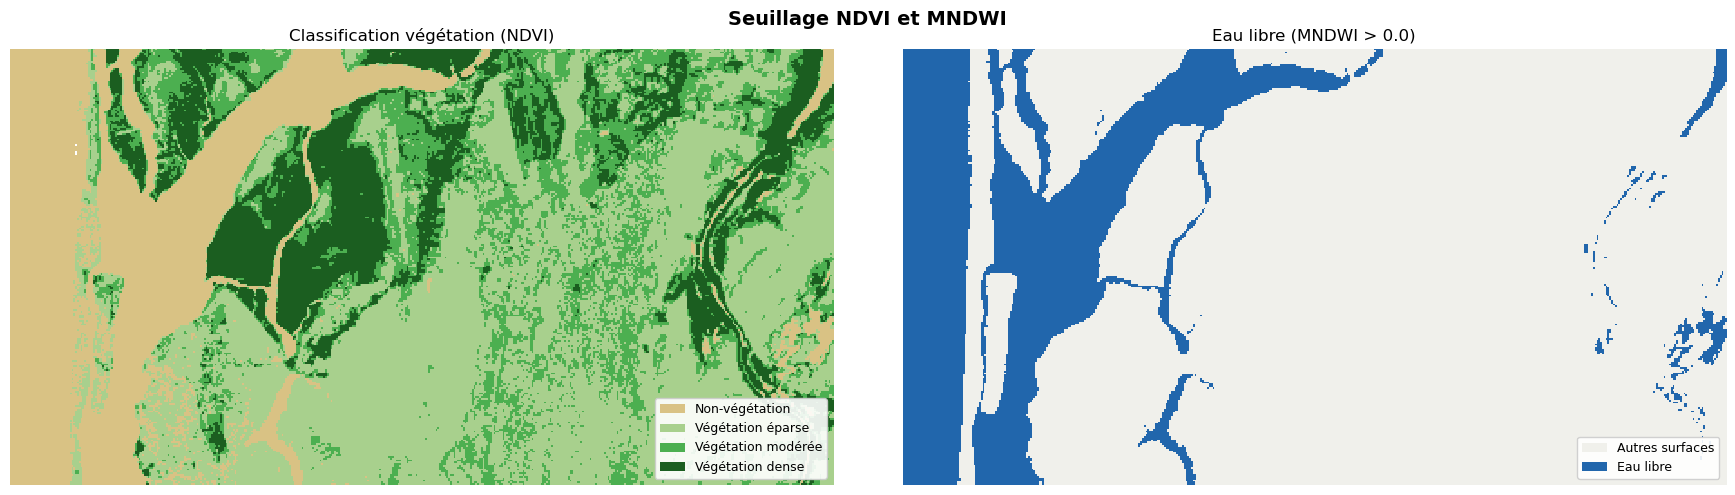

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Classes végétation
cmap_veg = mcolors.ListedColormap([i[2] for i in infos])
norm_veg = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_veg.N)
axes[0].imshow(ndvi_classes, cmap=cmap_veg, norm=norm_veg, interpolation='nearest')
axes[0].set_title('Classification végétation (NDVI)', fontsize=12)
axes[0].axis('off')
axes[0].legend(
    handles=[Patch(facecolor=c, label=l) for _, l, c in infos],
    loc='lower right', fontsize=9, framealpha=0.9
)

# 2. Masque eau
eau_display = masque_eau.astype(float)
cmap_eau = mcolors.ListedColormap(['#f0f0eb', '#2166ac'])
axes[1].imshow(eau_display, cmap=cmap_eau, interpolation='nearest')
axes[1].set_title(f'Eau libre (MNDWI > {SEUIL_EAU})', fontsize=12)
axes[1].axis('off')
axes[1].legend(
    handles=[
        Patch(facecolor='#f0f0eb', label='Autres surfaces'),
        Patch(facecolor='#2166ac', label='Eau libre'),
    ],
    loc='lower right', fontsize=9, framealpha=0.9
)

plt.suptitle('Seuillage NDVI et MNDWI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
#### Export des masques en GeoTIFF

On exporte les résultats en fichiers `.tif` géoréférencés pour pouvoir les charger dans QGIS ou les réutiliser dans d'autres analyses. On s'appuie sur le profil (`profile`) de l'image source pour conserver le même système de coordonnées et la même emprise.

In [26]:
out_dir = "data/indices_1985"
os.makedirs(out_dir, exist_ok=True)

coords = indices['NDVI'].coords
dims = indices['NDVI'].dims

ndvi_cls_da = xr.DataArray(ndvi_classes.astype("uint8"), coords=coords, dims=dims)
ndvi_cls_da.attrs["classes"] = {
    0: "Non-végétation",
    1: "Végétation éparse",
    2: "Végétation modérée",
    3: "Végétation dense"
}

masque_eau_da = xr.DataArray(masque_eau.astype("uint8"), coords=coords, dims=dims)
masque_eau_da.attrs["classes"] = {
    0: "Non-eau",
    1: "Eau"
}

masks = {'pixels_ndvi': ndvi_cls_da, 'pixel_eau': masque_eau_da}

for name, arr in masks.items(): 
    arr = arr.rio.write_crs(da_2015.rio.crs) 
    arr = arr.rio.write_transform(da_2015.rio.transform()) 
    arr.rio.to_raster(f"{out_dir}/{name}.tif")

---
### Exercices

**Exercice 1 — Calculer et visualiser le NDVI (image 2025)**

Objectif : charger le GeoTIFF 2025, renommer les bandes, calculer le NDVI et afficher :
- la carte NDVI,
- l'histogramme des valeurs,
- la valeur moyenne de NDVI sur l'image.

Remarque : le fichier attendu est `data/images-RS/L08_2025.tif`. Complétez le code ci-dessous si besoin.

**Exercice 2 — Détection des masses d'eau (image 2025)**

Objectif : à partir de la même image 2025, calculer le MNDWI, appliquer un seuillage (MNDWI > 0) en combinant NDVI pour exclure la végétation, puis estimer la surface en km² des pixels détectés comme eau libre.

Indications : utilisez `spyndex.computeIndex('MNDWI', params=...)` et `da_2025.rio.resolution()` pour obtenir la résolution des pixels.

**Exercice 3 — Identifier les zones bâties (image 2025)**

Objectif : utiliser le NDBI combiné au NDVI pour extraire une estimation simple des zones bâties (par exemple : NDBI > 0 et NDVI < 0.2). Afficher la carte et calculer la proportion de la surface totale classée comme bâti.

Indication : NDBI se calcule avec SWIR1 et NIR (spyndex index `NDBI`).